# Post-2050 predicted TREFMXAV_U analysis  

This notebook analyses the post-2050 predictions generated by the final XGBoost model.

In [2]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()

if cwd.name == "notebooks":
    PROJECT_ROOT = cwd.parent

else:
    PROJECT_ROOT = cwd

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: /Users/jacobwoodland/Semester 2/EART60702/Assignment 2/Project Folder/eds_project2


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

from src.config import TABLES_DIR, FIGURES_DIR

In [4]:
post2050 = pd.read_csv(TABLES_DIR / "post2050_predictions.csv")

In [5]:
print(post2050.columns.tolist())
print(post2050.shape)
post2050.head()

['scenario', 'time', 'TREFMXAV_U', 'TREFHT', 'FLNS', 'FSNS', 'PRECT', 'PRSN', 'QBOT', 'UBOT', 'VBOT', 'lat', 'lon', 'year', 'month', 'monthly_sin', 'monthly_cos', 'wind_speed', 'TREFHT_lag1', 'PRECT_lag1', 'PRSN_lag1', 'FLNS_lag1', 'FSNS_lag1', 'QBOT_lag1', 'wind_speed_lag1', 'pred_TREFMXAV_U']
(93744, 26)


,scenario,time,TREFMXAV_U,TREFHT,FLNS,FSNS,PRECT,PRSN,QBOT,UBOT,...,monthly_cos,wind_speed,TREFHT_lag1,PRECT_lag1,PRSN_lag1,FLNS_lag1,FSNS_lag1,QBOT_lag1,wind_speed_lag1,pred_TREFMXAV_U
0,3,2050-01-01 00:00:00,285.80136,283.99677,37.516384,30.577051,2.521736e-06,1.648166e-14,0.006410,5.582342,...,8.660254e-01,7.836511,282.48373,4.135034e-07,2.540881e-14,58.289960,34.724420,0.005628,2.141264,285.69520
1,3,2050-02-01 00:00:00,285.41544,282.44060,66.326950,79.958450,8.721353e-07,3.524978e-14,0.005101,-0.701649,...,5.000000e-01,2.899583,283.99677,2.521736e-06,1.648166e-14,37.516384,30.577051,0.006410,7.836511,285.14316
2,3,2050-03-01 00:00:00,284.60860,281.54675,60.539158,117.381300,7.776718e-07,7.428997e-10,0.004784,-1.219418,...,6.123234e-17,1.402428,282.44060,8.721353e-07,3.524978e-14,66.326950,79.958450,0.005101,2.899583,284.75696
3,3,2050-04-01 00:00:00,289.54980,284.74783,59.838787,176.792770,9.672199e-07,2.614217e-14,0.005760,1.609725,...,-5.000000e-01,1.632368,281.54675,7.776718e-07,7.428997e-10,60.539158,117.381300,0.004784,1.402428,289.38780
4,3,2050-05-01 00:00:00,294.81363,288.92102,66.239780,248.411360,2.893328e-07,2.476724e-15,0.007576,-2.432174,...,-8.660254e-01,3.282235,284.74783,9.672199e-07,2.614217e-14,59.838787,176.792770,0.005760,1.632368,294.00480


## Annual prediction trajectories by scenario

Aggregate predictions to annual means for each scenario

In [6]:
annual_preds = (
    post2050
    .groupby(["scenario", "year"])["pred_TREFMXAV_U"]
    .mean()
    .reset_index()
)

annual_preds.head()

,scenario,year,pred_TREFMXAV_U
0,3,2050,288.701367
1,3,2051,288.900843
2,3,2052,288.868417
3,3,2053,288.693304
4,3,2054,288.705980


In [7]:
# Check all scenarios and full period are there

annual_preds.groupby("scenario")["year"].agg(["min", "max", "count"])

,min,max,count
scenario,,,
3,2050,2080,31
4,2050,2080,31
5,2050,2080,31
6,2050,2080,31
7,2050,2080,31
8,2050,2080,31


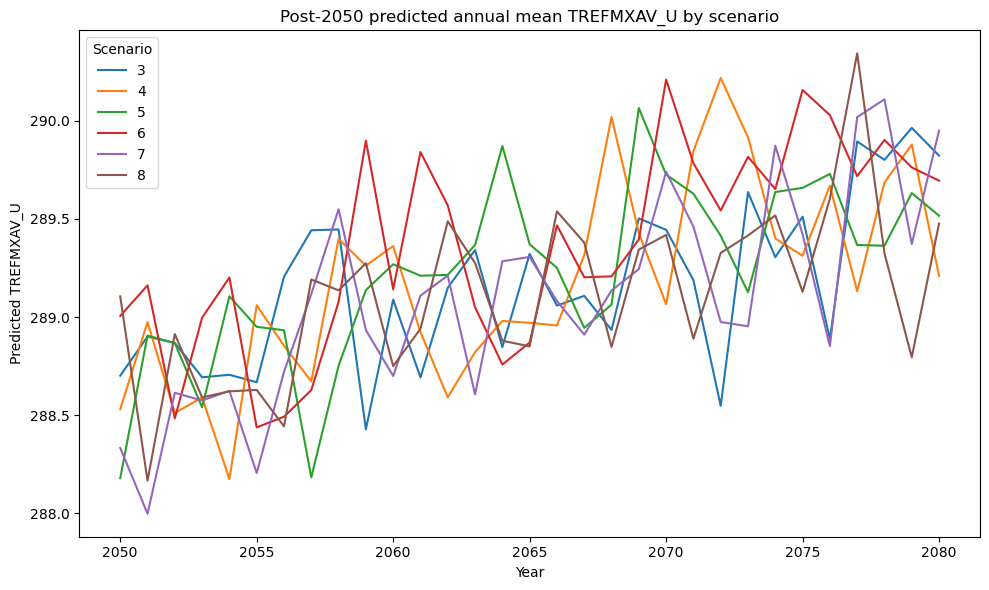

In [11]:
plt.figure(figsize=(10, 6))

for scenario, grp in annual_preds.groupby("scenario"):
    plt.plot(grp["year"], grp["pred_TREFMXAV_U"], label=scenario)

plt.title("Post-2050 predicted annual mean TREFMXAV_U by scenario")
plt.xlabel("Year")
plt.ylabel("Predicted TREFMXAV_U")
plt.legend(title="Scenario")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "post2050_annual_trajectories_by_scenario_raw.png", dpi=300, bbox_inches="tight")
plt.show()

In [9]:
annual_summary = (
    annual_preds
    .groupby("scenario")["pred_TREFMXAV_U"]
    .agg(["mean", "min", "max"])
    .reset_index()
)

annual_summary

,scenario,mean,min,max
0,3,289.164900,288.428441,289.963739
1,4,289.184918,288.175240,290.217960
2,5,289.225299,288.179486,290.064985
3,6,289.359944,288.438131,290.210075
4,7,289.096407,287.998383,290.109453
5,8,289.116446,288.167002,290.343588


In [10]:
annual_summary.to_csv(TABLES_DIR / "post2050_annual_summary_by_scenario.csv", index=False)

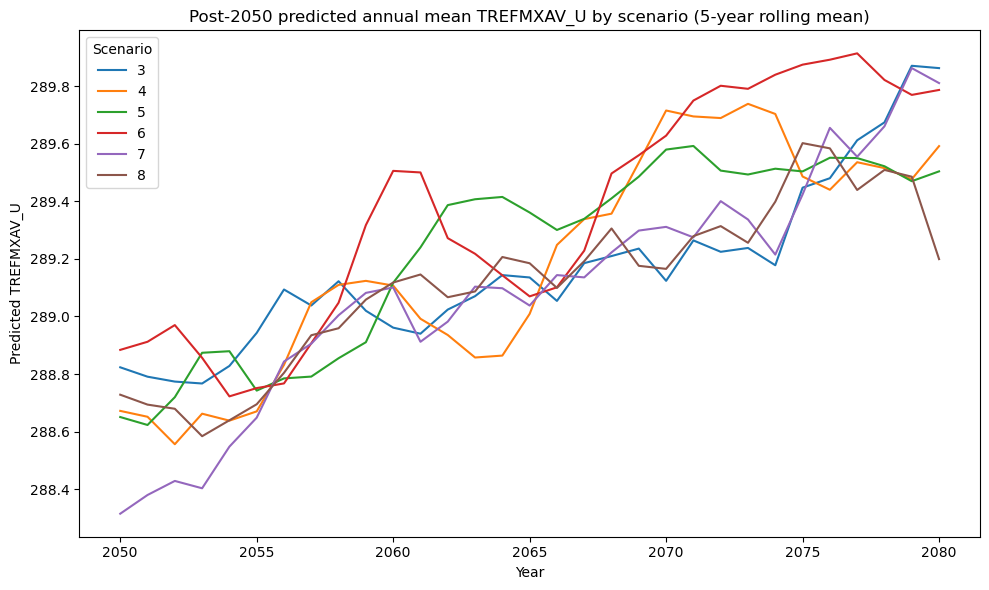

In [12]:
# Improve the plot by smoothing some of the noise using a 5-year rolling avergae

annual_preds = annual_preds.sort_values(["scenario", "year"]).copy()

annual_preds["pred_smooth_5yr"] = (
    annual_preds
    .groupby("scenario")["pred_TREFMXAV_U"]
    .transform(lambda s: s.rolling(window=5, center=True, min_periods=1).mean())
)

plt.figure(figsize=(10, 6))

for scenario, grp in annual_preds.groupby("scenario"):
    plt.plot(grp["year"], grp["pred_smooth_5yr"], label=scenario)

plt.title("Post-2050 predicted annual mean TREFMXAV_U by scenario (5-year rolling mean)")
plt.xlabel("Year")
plt.ylabel("Predicted TREFMXAV_U")
plt.legend(title="Scenario")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "post2050_annual_trajectories_by_scenario_5yr_rolling_mean.png", dpi=300, bbox_inches="tight")
plt.show()

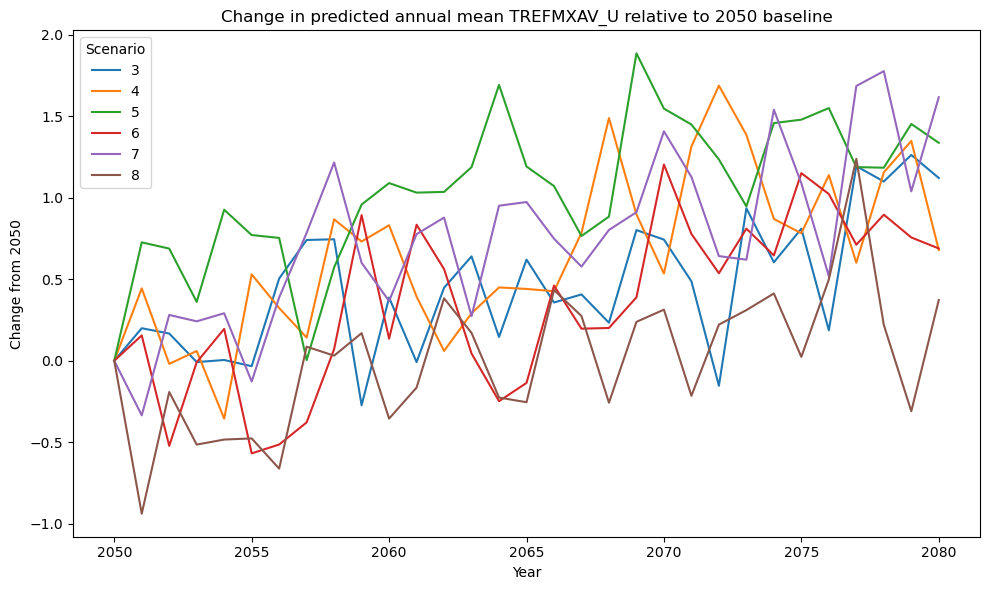

In [13]:
# PLot relative to 2050 baseline year

annual_change = annual_preds.copy()

baseline = (
    annual_change[annual_change["year"]==2050]
    .set_index("scenario")["pred_TREFMXAV_U"]
)

annual_change["baseline_2050"] = annual_change["scenario"].map(baseline)
annual_change["change_from_2050"] = annual_change["pred_TREFMXAV_U"] - annual_change["baseline_2050"]

plt.figure(figsize=(10, 6))

for scenario, grp in annual_change.groupby("scenario"):
    plt.plot(grp["year"], grp["change_from_2050"], label=scenario)

plt.title("Change in predicted annual mean TREFMXAV_U relative to 2050 baseline")
plt.xlabel("Year")
plt.ylabel("Change from 2050")
plt.legend(title="Scenario")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "post2050_annual_change_relative_to_2050_by_scenario.png", dpi=300, bbox_inches="tight")
plt.show()

In [14]:
# Summarise over decades

def assign_period(year):
    if 2050 <= year <= 2059:
        return "2050s"
    elif 2060 <= year <= 2069:
        return "2060s"
    else:
        return "2070s"
    
annual_preds["period"] = annual_preds["year"].apply(assign_period)

period_summary = (
    annual_preds
    .groupby(["scenario", "period"])["pred_TREFMXAV_U"]
    .mean()
    .reset_index()
)

period_summary

,scenario,period,pred_TREFMXAV_U
0,3,2050s,288.906087
1,3,2060s,289.104639
2,3,2070s,289.454968
3,4,2050s,288.802996
4,4,2060s,289.136921
5,4,2070s,289.575755
6,5,2050s,288.755590
7,5,2060s,289.362906
8,5,2070s,289.527209
9,6,2050s,288.938622


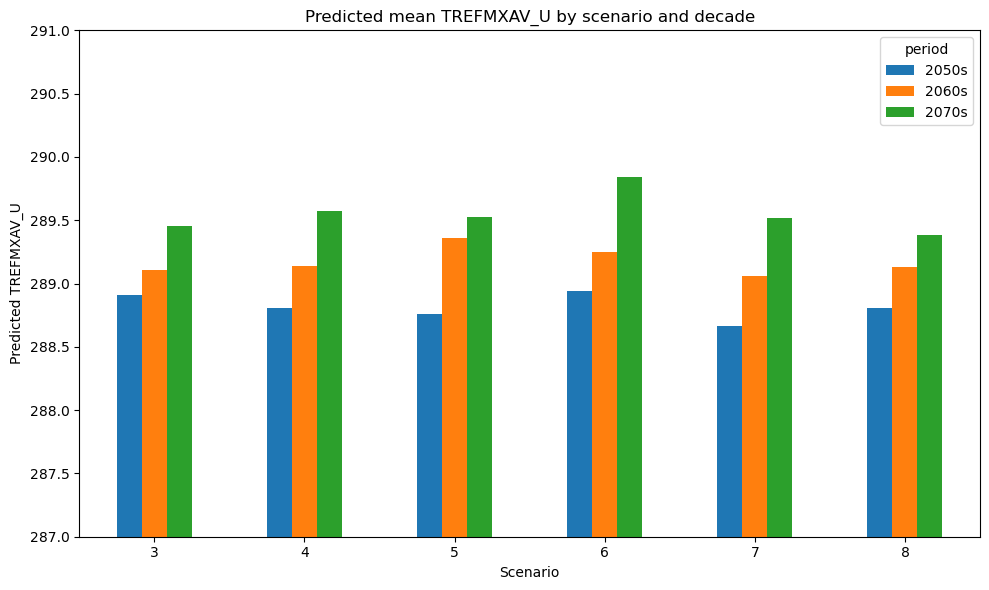

In [22]:
period_pivot = period_summary.pivot(index="scenario", columns="period", values="pred_TREFMXAV_U")

ax = period_pivot.plot(kind="bar", figsize=(10, 6))
ax.set_title("Predicted mean TREFMXAV_U by scenario and decade")
ax.set_xlabel("Scenario")
ax.set_ylabel("Predicted TREFMXAV_U")
ax.set_ylim(287,291)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "mean_predicted_TREFMXAV_U_by_scenario_and_decade.png", dpi=300, bbox_inches="tight")
plt.show()

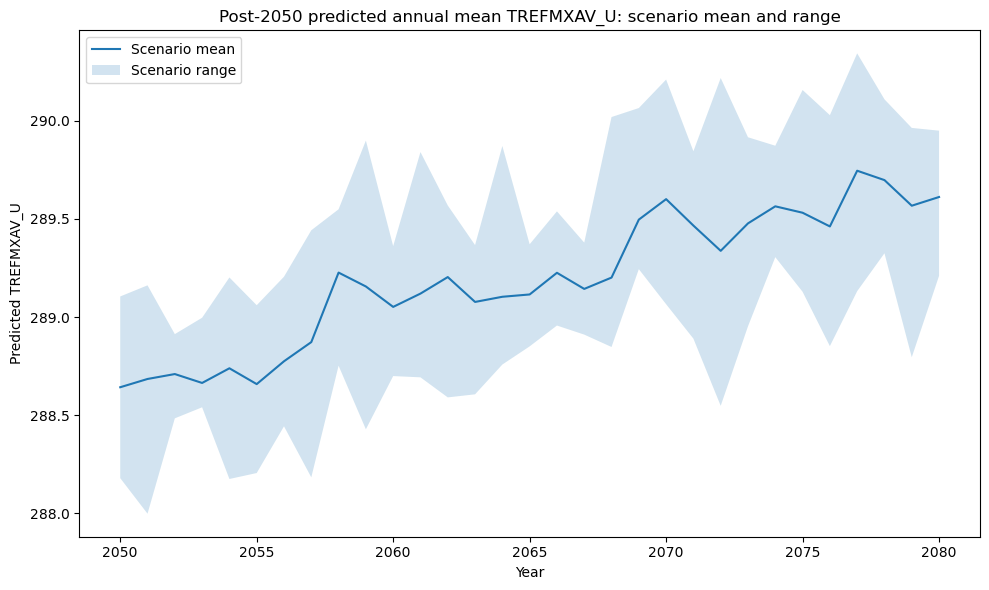

In [24]:
# Overall model behaviour across scenarios with spread

ensemble_summary = (
    annual_preds
    .groupby("year")["pred_TREFMXAV_U"]
    .agg(["mean", "min", "max"])
    .reset_index()
)

plt.figure(figsize=(10, 6))
plt.plot(ensemble_summary["year"], ensemble_summary["mean"], label="Scenario mean")
plt.fill_between(
    ensemble_summary["year"],
    ensemble_summary["min"],
    ensemble_summary["max"],
    alpha=0.2,
    label="Scenario range"
)

plt.title("Post-2050 predicted annual mean TREFMXAV_U: scenario mean and range")
plt.xlabel("Year")
plt.ylabel("Predicted TREFMXAV_U")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "post2050_annual_mean_predictions_scenario_mean_and_range.png", dpi=300, bbox_inches="tight")
plt.show()